# 3.5 Escalonamento de Máquina (*Machine Scheduling*) — versão Julia

> Material de aula — Otimização / Programação Inteira Mista (MILO) e disjunções.
> Porte para **Julia (JuMP + HiGHS)** do notebook **3.5 Machine Scheduling** do livro
> *Hands-On Mathematical Optimization with Python* (MO-book), com texto em português.

Estudamos o problema de **escalonar um conjunto de tarefas (*jobs*) em uma única máquina**,
dados o instante de liberação (*release*), a duração (*duration*) e o prazo (*due*) de cada
tarefa. O objetivo é encontrar uma **sequência** que respeite os prazos; quando isso não é
possível, busca-se o "menos ruim", minimizando uma métrica de desempenho.

Comparamos três caminhos:

1. **Regras empíricas / heurísticas** — FIFO, EDD e SPT;
2. **Modelo ótimo MILO** via reformulação *big-M* em JuMP (é exatamente o que a transformação
   `gdp.bigm` do Pyomo aplica por baixo);
3. **Alternativa idiomática** com `DisjunctiveProgramming.jl` (o análogo do componente
   `Disjunction` do Pyomo), mostrada de forma opcional ao final.

Os dados do exemplo vêm do Capítulo 5 do livro de Guéret, Prins e Sevaux,
*Applications of Optimization with Xpress-MP* (Dash Optimization, 2000).

---

### Nota de porte (Python → Julia)

| Pyomo (Python) | JuMP (Julia) |
| --- | --- |
| `pyo.ConcreteModel()` | `Model(HiGHS.Optimizer)` |
| `pyo.Var(..., domain=NonNegativeReals)` | `@variable(model, 0 <= x[...] )` |
| `@m.Constraint(...)` | `@constraint(model, ...)` |
| `@m.Disjunction(..., xor=True)` | reformulação *big-M* explícita **ou** `DisjunctiveProgramming.jl` |
| `pandas.DataFrame` | `DataFrames.DataFrame` |
| `matplotlib` | `Plots.jl` |

## Preâmbulo: pacotes e solver

A célula abaixo garante os pacotes necessários (instala apenas se faltarem) e define um
`SOLVER` global apontando para o **HiGHS**, análogo ao objeto `SOLVER` do notebook original.

In [1]:
import Pkg

# instala apenas o que estiver faltando (roda uma vez por ambiente)
function ensure(pkgs)
    for p in pkgs
        try
            @eval import $(Symbol(p))
        catch
            Pkg.add(p)
        end
    end
end

ensure(["JuMP", "HiGHS", "DataFrames", "Plots"])

In [2]:
using JuMP, HiGHS, DataFrames, Plots
gr()

# Optimizer global reutilizado em todos os modelos (análogo ao SOLVER do Pyomo)
const SOLVER = HiGHS.Optimizer

HiGHS.Optimizer

## Descrição do problema

> "Qual tarefa deve ser feita a seguir?" é uma pergunta que aparece em inúmeros contextos: um
> estudante decidindo qual exercício fazer, um entregador roteirizando pacotes, um garçom
> atendendo mesas, um processador escalonando *threads* ou uma máquina em uma linha de montagem.

Em vez de aplicar apenas heurísticas, **modelamos** o problema e o resolvemos com otimização.

### Dados das tarefas

Cada linha corresponde a uma tarefa, com seu instante de liberação (`release`), duração
(`duration`) e prazo (`due`).

In [13]:
# jobs = DataFrame(
#     job      = ["A", "B", "C", "D", "E", "F", "G"],
#     release  = [2,   5,   4,   0,   0,   8,   9],
#     duration = [5,   6,   8,   4,   2,   3,   2],
#     due      = [10,  21,  15,  10,  5,   15,  22],
# )

jobs = DataFrame(
    job      = ["J1", "J2", "J3", "J4", "J5", "J6", "J7", "J8", "J9", "J10", "J11", "J12", "J13", "J14", "J15"],
    release  = [10,   27,   7,    7,    17,   11,   0,    10,   5,    20,    18,    29,    19,    26,    21],
    duration = [2,    3,    9,    1,    1,    2,    1,    5,    3,    7,     9,     3,     5,     3,     4],
    due      = [13,   46,   32,   16,   34,   20,   7,    16,   18,   28,    27,    42,    37,    29,    35],
)

Row,job,release,duration,due
,String,Int64,Int64,Int64
1,J1,10,2,13
2,J2,27,3,46
3,J3,7,9,32
4,J4,7,1,16
5,J5,17,1,34
6,J6,11,2,20
7,J7,0,1,7
8,J8,10,5,16
9,J9,5,3,18


### Dados do escalonamento

Um escalonamento é representado por um `DataFrame` com as colunas `start`, `finish` e `past`
(o atraso, isto é, quanto a tarefa passou do prazo). A função abaixo constrói o escalonamento
correspondente a uma dada **sequência** de tarefas.

In [14]:
function schedule_jobs(jobs::DataFrame, seq)
    rel = Dict(jobs.job .=> jobs.release)
    dur = Dict(jobs.job .=> jobs.duration)
    due = Dict(jobs.job .=> jobs.due)

    sched = DataFrame(job = String[], start = Float64[], finish = Float64[], past = Float64[])
    t = 0.0
    for j in seq
        t = max(t, rel[j])
        s = t
        t += dur[j]
        f = t
        push!(sched, (j, s, f, max(0.0, f - due[j])))
    end
    return sched
end

schedule = schedule_jobs(jobs, jobs.job)

Row,job,start,finish,past
,String,Float64,Float64,Float64
1,J1,10.0,12.0,0.0
2,J2,27.0,30.0,0.0
3,J3,30.0,39.0,7.0
4,J4,39.0,40.0,24.0
5,J5,40.0,41.0,7.0
6,J6,41.0,43.0,23.0
7,J7,43.0,44.0,37.0
8,J8,44.0,49.0,33.0
9,J9,49.0,52.0,34.0


### Gráfico de Gantt

A função `gantt` reproduz o gráfico de Gantt com `Plots.jl`. A janela cinza indica o intervalo
`release`–`due`; barras **verdes** são tarefas concluídas no prazo e **vermelhas**, atrasadas.

Com a estratégia "ordem do dataframe", o atraso total é 403.0


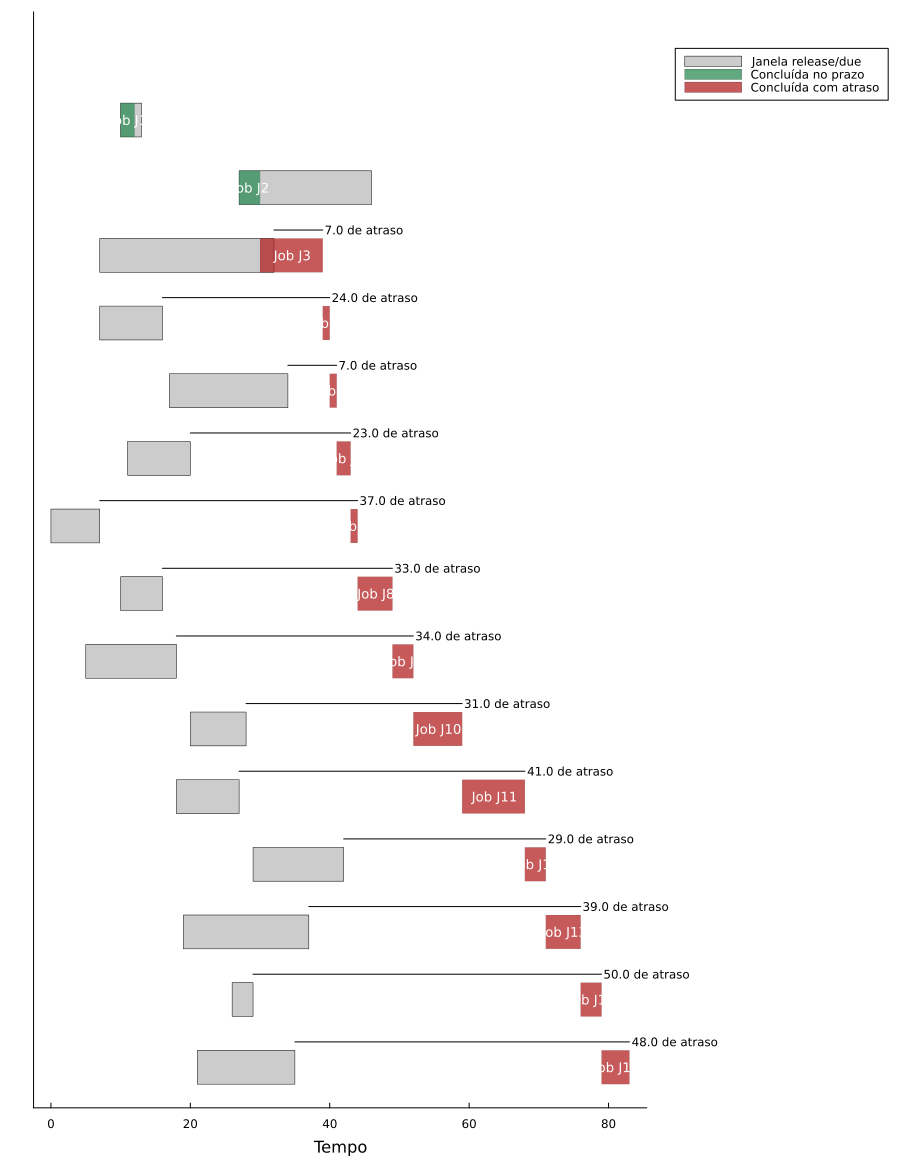

In [15]:
function gantt(jobs::DataFrame, schedule::DataFrame; title = "")
    rel = Dict(jobs.job .=> jobs.release)
    due = Dict(jobs.job .=> jobs.due)
    srt = Dict(schedule.job .=> schedule.start)
    fin = Dict(schedule.job .=> schedule.finish)
    pst = Dict(schedule.job .=> schedule.past)

    w = 0.25
    n = nrow(jobs)
    plt = plot(; legend = :outertopright, grid = false, yticks = false,
                 xlabel = "Tempo", ylabel = "Tarefas", size = (900, 70n + 120))

    shown_win = false; shown_on = false; shown_late = false
    for (k, j) in enumerate(jobs.job)
        r, d = rel[j], due[j]
        s, f = srt[j], fin[j]
        y = -float(k)

        # janela release-due
        lbl = shown_win ? "" : "Janela release/due"; shown_win = true
        plot!(plt, Shape([r, d, d, r], [y - w, y - w, y + w, y + w]);
              fillcolor = :black, fillalpha = 0.2, linecolor = :black,
              linewidth = 0.5, label = lbl)

        # janela start-finish
        if f <= d
            lbl = shown_on ? "" : "Concluída no prazo"; shown_on = true
            col = :seagreen
        else
            lbl = shown_late ? "" : "Concluída com atraso"; shown_late = true
            col = :firebrick
        end
        plot!(plt, Shape([s, f, f, s], [y - w, y - w, y + w, y + w]);
              fillcolor = col, fillalpha = 0.75, linewidth = 0, label = lbl)
        annotate!(plt, (s + f) / 2, y, text("Job $j", :white, :center, 9))

        # marcação de atraso
        if f > d
            plot!(plt, [d, f], [y + 1.5w, y + 1.5w]; color = :black, linewidth = 1, label = "")
            annotate!(plt, f + 0.4, y + 1.5w,
                      text("$(round(pst[j]; digits = 1)) de atraso", :left, 8))
        end
    end

    total = sum(schedule.past)
    println("Com a estratégia \"$title\", o atraso total é $(round(total; digits = 1))")
    plot!(plt; ylims = (-n - 0.6, 0.6))
    return plt
end

gantt(jobs, schedule; title = "ordem do dataframe")

## Regras empíricas de escalonamento

Implementamos três regras empíricas clássicas para uma única máquina:

- **First in, first out (FIFO)** — primeiro a chegar, primeiro a ser atendido (ordena por `release`);
- **Earliest due date (EDD)** — prazo mais cedo primeiro (ordena por `due`);
- **Shortest processing time (SPT)** — menor duração primeiro (ordena por `duration`).

> Usamos ordenação **estável** (`alg = MergeSort`) para que empates (p.ex. tarefas E e G, ambas
> com duração 2) sejam resolvidos de forma determinística — reproduzindo os números do livro.

### First-in, first-out (FIFO)

Com a estratégia "First in, First out", o atraso total é 139.0


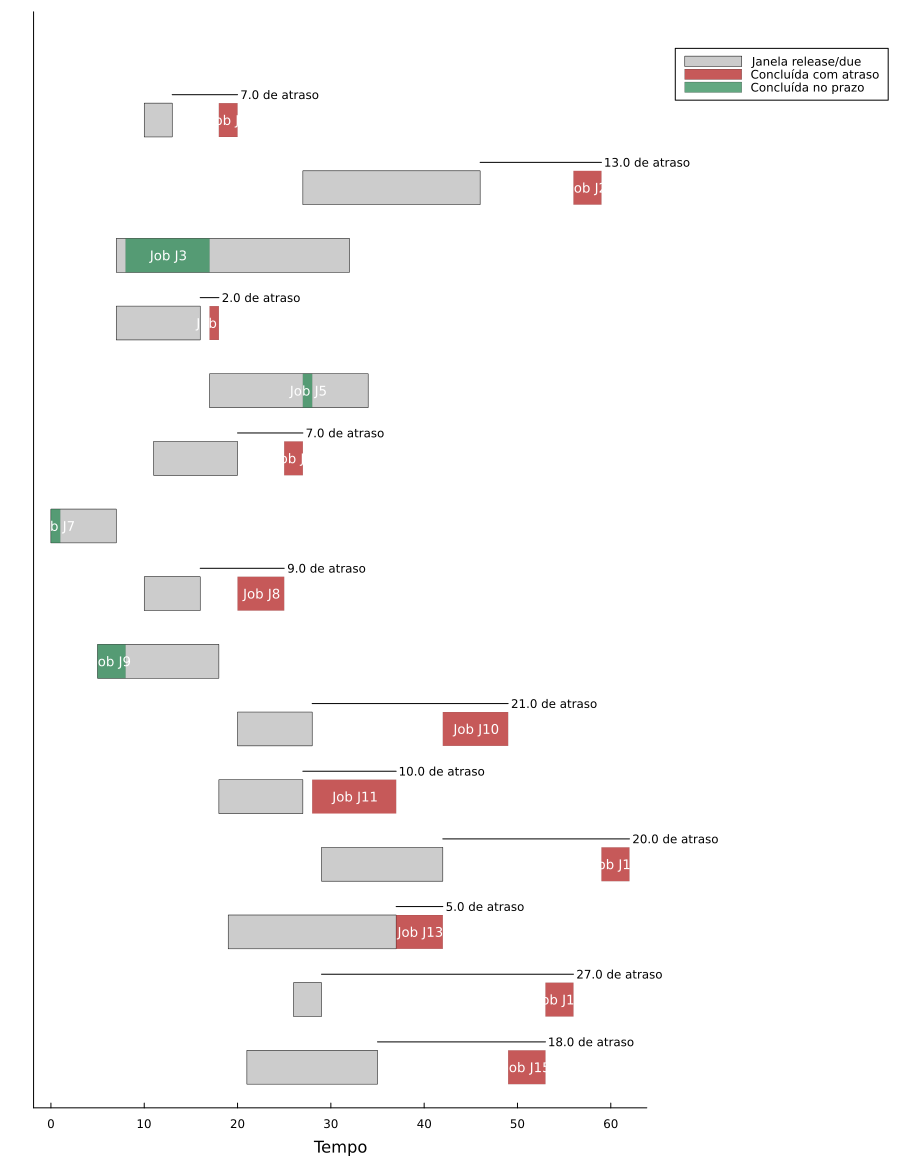

In [16]:
fifo = schedule_jobs(jobs, sort(jobs, :release; alg = MergeSort).job)
gantt(jobs, fifo; title = "First in, First out")

### Earliest due date (EDD)

Com a estratégia "Earliest due date", o atraso total é 162.0


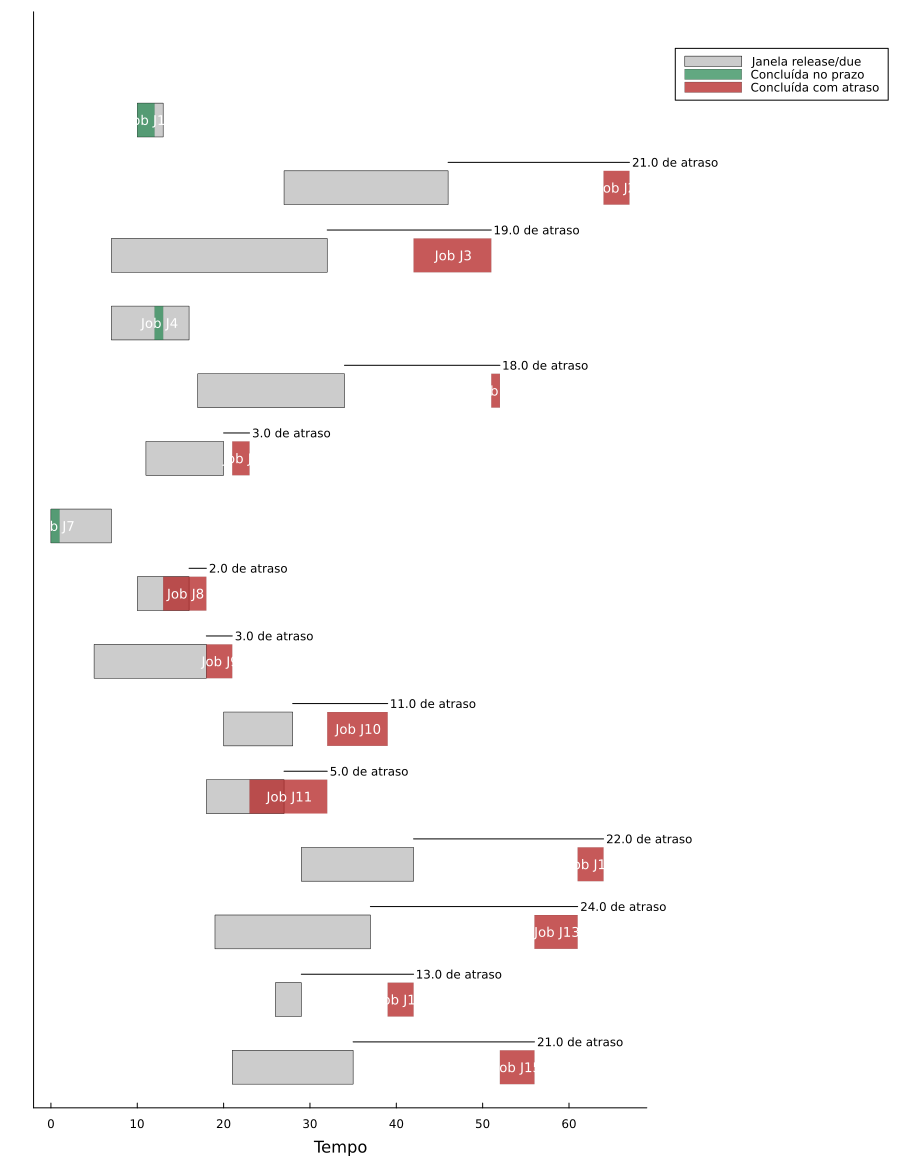

In [17]:
edd = schedule_jobs(jobs, sort(jobs, :due; alg = MergeSort).job)
gantt(jobs, edd; title = "Earliest due date")

### Shortest processing time (SPT)

Com a estratégia "Shortest Processing Time", o atraso total é 224.0


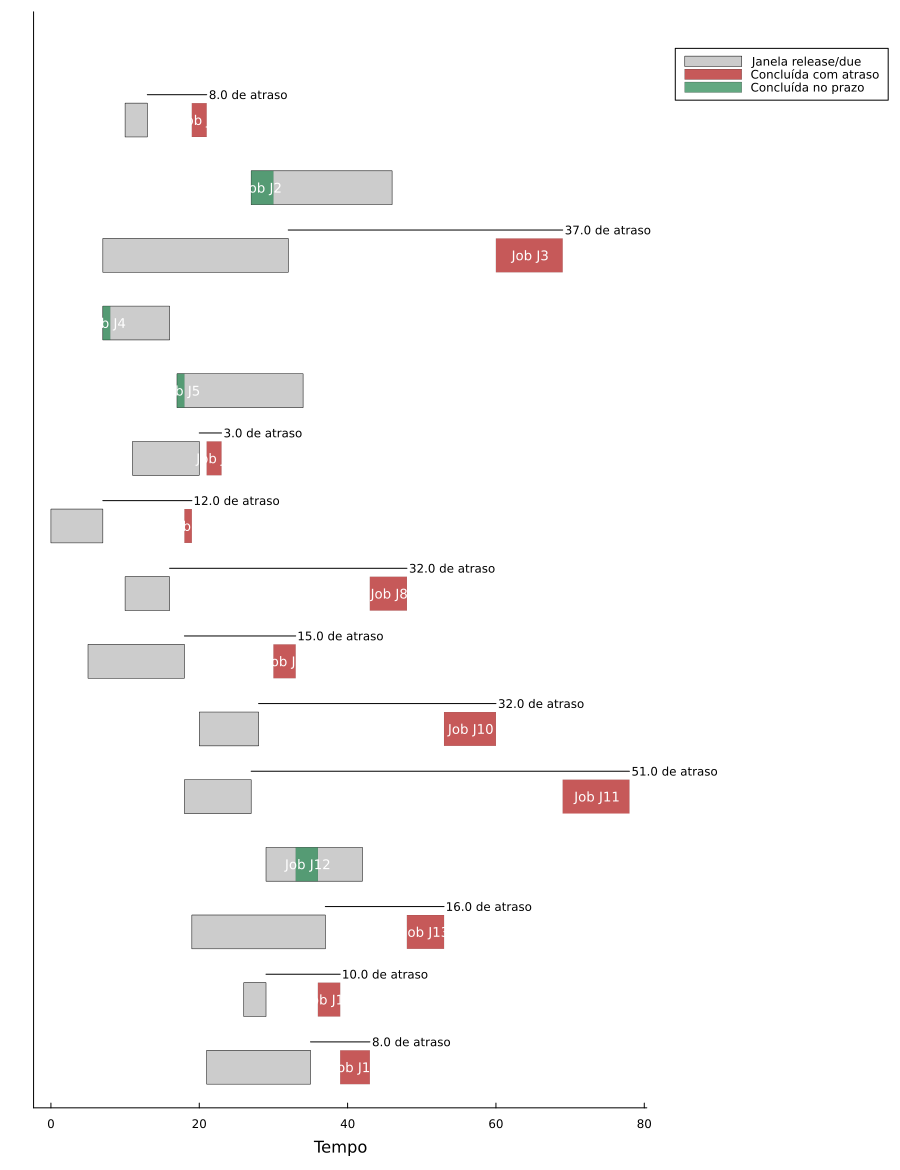

In [18]:
spt = schedule_jobs(jobs, sort(jobs, :duration; alg = MergeSort).job)
gantt(jobs, spt; title = "Shortest Processing Time")

## Escalonamento ótimo

### Dados, variáveis e objetivo

| Símbolo | Descrição |
| --- | --- |
| $\text{release}_j$ | quando a tarefa $j$ fica disponível |
| $\text{duration}_j$ | quanto tempo a tarefa $j$ leva |
| $\text{due}_j$ | quando a tarefa $j$ vence |

| Símbolo | Descrição |
| --- | --- |
| $\text{start}_j$ | quando a tarefa $j$ inicia |
| $\text{finish}_j$ | quando a tarefa $j$ termina |
| $\text{past}_j$ | quanto a tarefa $j$ está atrasada |

Minimizamos a **soma dos atrasos**:

$$
\min \sum_j \text{past}_j
$$

sujeito a:

$$
\begin{aligned}
\text{start}_{j} & \geq \text{release}_{j} \\
\text{finish}_j & = \text{start}_j + \text{duration}_j \\
\text{past}_{j} & \geq \text{finish}_j - \text{due}_{j} \\
\text{past}_{j} & \geq 0
\end{aligned}
$$

### A restrição-chave: a disjunção

Nenhum par de tarefas pode ocupar a máquina ao mesmo tempo. Para cada par único $(i, j)$ com
$i < j$: ou $i$ termina antes de $j$ iniciar, ou $j$ termina antes de $i$ iniciar — uma
**disjunção**:

$$
\begin{bmatrix} \text{finish}_i \leq \text{start}_j \end{bmatrix}
\ \veebar \
\begin{bmatrix} \text{finish}_j \leq \text{start}_i \end{bmatrix}
\qquad \forall\, i < j
$$

Em Julia, tratamos a disjunção pela reformulação **big-M**, introduzindo uma binária
$z_{ij} \in \{0,1\}$ por par:

$$
\begin{aligned}
\text{finish}_i & \leq \text{start}_j + M\, z_{ij} \\
\text{finish}_j & \leq \text{start}_i + M\, (1 - z_{ij})
\end{aligned}
$$

Esta é exatamente a reformulação que o Pyomo aplica com `gdp.bigm`. A formulação de alto nível
com `DisjunctiveProgramming.jl` é mostrada como alternativa opcional ao final do notebook.

In [19]:
function machine_schedule_milo(jobs::DataFrame; bigM = 10_000, maxtime = 100)
    JOBS  = jobs.job
    rel   = Dict(jobs.job .=> jobs.release)
    dur   = Dict(jobs.job .=> jobs.duration)
    due   = Dict(jobs.job .=> jobs.due)
    PAIRS = [(i, j) for i in JOBS for j in JOBS if i < j]

    model = Model(SOLVER)
    #set_silent(model)
    set_time_limit_sec(model, 60.0)

    @variable(model, 0 <= start[JOBS]  <= maxtime)
    @variable(model, 0 <= finish[JOBS] <= maxtime)
    @variable(model, 0 <= past[JOBS]   <= maxtime)
    @variable(model, z[PAIRS], Bin)

    @constraint(model, [j in JOBS], start[j]  >= rel[j])
    @constraint(model, [j in JOBS], finish[j] == start[j] + dur[j])
    @constraint(model, [j in JOBS], past[j]   >= finish[j] - due[j])

    # reformulação big-M da disjunção (não sobrepor tarefas)
    @constraint(model, [p in PAIRS], finish[p[1]] <= start[p[2]] + bigM * (1 - z[p]))
    @constraint(model, [p in PAIRS], finish[p[2]] <= start[p[1]] + bigM * z[p])

    @objective(model, Min, sum(past[j] for j in JOBS))

    optimize!(model)
    return model
end

function schedule_from_model(model, jobs::DataFrame)
    DataFrame(
        job    = jobs.job,
        start  = [round(value(model[:start][j]);  digits = 2) for j in jobs.job],
        finish = [round(value(model[:finish][j]); digits = 2) for j in jobs.job],
        past   = [round(value(model[:past][j]);   digits = 2) for j in jobs.job],
    )
end

model = machine_schedule_milo(jobs)
optimalschedule = schedule_from_model(model, jobs)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 255 rows; 150 cols; 705 nonzeros; 105 integer variables (105 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+04]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+02]
  RHS     [1e+00, 1e+04]
Presolving model
225 rows, 135 cols, 660 nonzeros 0s
221 rows, 133 cols, 650 nonzeros 0s
Presolve reductions: rows 221(-34); columns 133(-17); nonzeros 650(-55) 

Solving MIP model with:
   221 rows
   133 cols (105 binary, 0 integer, 0 implied int., 28 continuous, 0 domain fixed)
   650 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

 

Row,job,start,finish,past
,String,Float64,Float64,Float64
1,J1,10.0,12.0,0.0
2,J2,42.0,45.0,0.0
3,J3,45.0,54.0,22.0
4,J4,8.0,9.0,0.0
5,J5,19.0,20.0,0.0
6,J6,17.0,19.0,0.0
7,J7,0.0,1.0,0.0
8,J8,12.0,17.0,1.0
9,J9,5.0,8.0,0.0


Com a estratégia "Minimizar atraso total", o atraso total é 62.0


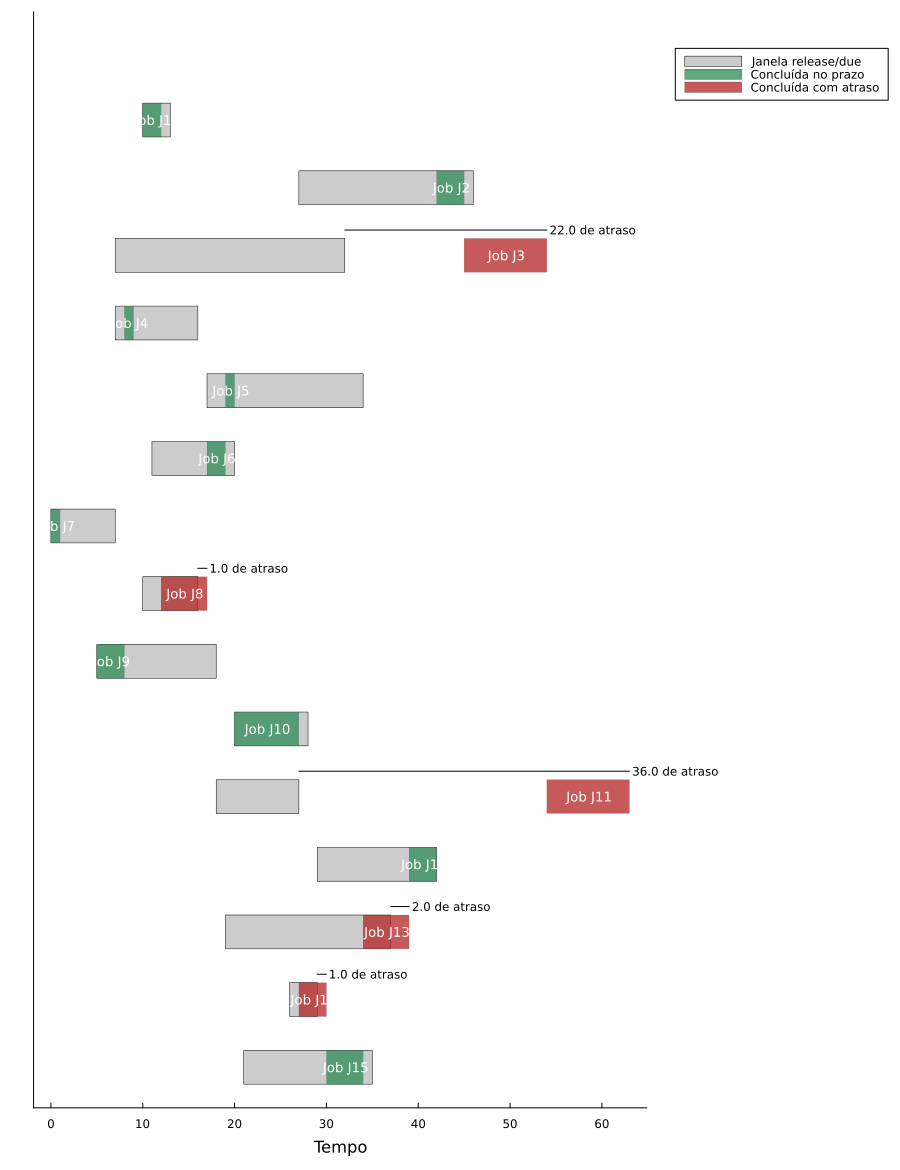

In [20]:
gantt(jobs, optimalschedule; title = "Minimizar atraso total")

In [12]:
model

A JuMP Model
├ solver: HiGHS
├ objective_sense: MIN_SENSE
│ └ objective_function_type: AffExpr
├ num_variables: 42
├ num_constraints: 126
│ ├ AffExpr in MOI.EqualTo{Float64}: 7
│ ├ AffExpr in MOI.GreaterThan{Float64}: 14
│ ├ AffExpr in MOI.LessThan{Float64}: 42
│ ├ VariableRef in MOI.GreaterThan{Float64}: 21
│ ├ VariableRef in MOI.LessThan{Float64}: 21
│ └ VariableRef in MOI.ZeroOne: 21
└ Names registered in the model
  └ :finish, :past, :start, :z

A solução obtida pela otimização (**atraso total = 16**) **supera** qualquer uma das regras
empíricas. Ainda assim, heurísticas continuam essenciais para problemas de grande porte.

### Observação sobre o big-M

O valor de $M$ deve ser grande o bastante para "desligar" a restrição inativa, mas não maior do
que o necessário: $M$ excessivo **enfraquece a relaxação linear** e tende a tornar a resolução
mais lenta. Um limitante natural aqui é o horizonte de tempo (`maxtime`).

## Síntese

| Estratégia | Atraso total |
| --- | --- |
| Ordem do dataframe | 68 |
| SPT (menor processamento) | 51 |
| FIFO (primeiro a chegar) | 31 |
| EDD (prazo mais cedo) | 27 |
| **Ótimo (MILO / big-M)** | **16** |

In [ ]:
estrategias = ["Ordem df", "SPT", "FIFO", "EDD", "Ótimo"]
atrasos     = [68, 51, 31, 27, 16]

bar(estrategias, atrasos;
    legend = false, ylabel = "Atraso total", title = "Heurísticas × ótimo",
    fillcolor = :steelblue, size = (820, 420))

Observações para a aula:

- As regras empíricas são rápidas e simples, mas **subótimas** — a melhor delas (EDD = 27) ainda
  fica 11 unidades acima do ótimo.
- A reformulação **big-M** é equivalente à disjunção original; a qualidade da relaxação linear
  depende do valor de $M$.
- Para instâncias grandes, heurísticas (e meta-heurísticas) voltam a ser indispensáveis como
  ponto de partida ou solução de compromisso.

---

## (Opcional) Formulação disjuntiva de alto nível com `DisjunctiveProgramming.jl`

A célula abaixo expressa a **disjunção diretamente**, sem escrever o big-M à mão — é o análogo
em Julia do componente `Disjunction` do Pyomo. O pacote reformula o modelo (`BigM()` ou `Hull()`)
e resolve, devendo retornar a mesma solução ótima (atraso 16).

> **Requer o pacote extra `DisjunctiveProgramming.jl`.** A API pode variar entre versões;
> consulte a documentação do pacote se necessário. O caminho principal acima (JuMP + HiGHS puro)
> independe desta célula.

In [ ]:
# Opcional — descomente para executar (requer DisjunctiveProgramming.jl)
#
# ensure(["DisjunctiveProgramming"])
# using DisjunctiveProgramming
#
# function machine_schedule_gdp(jobs::DataFrame; maxtime = 100)
#     JOBS  = jobs.job
#     rel   = Dict(jobs.job .=> jobs.release)
#     dur   = Dict(jobs.job .=> jobs.duration)
#     due   = Dict(jobs.job .=> jobs.due)
#     PAIRS = [(i, j) for i in JOBS for j in JOBS if i < j]
#
#     model = GDPModel(SOLVER)
#     set_silent(model)
#
#     @variable(model, 0 <= start[JOBS]  <= maxtime)
#     @variable(model, 0 <= finish[JOBS] <= maxtime)
#     @variable(model, 0 <= past[JOBS]   <= maxtime)
#
#     @constraint(model, [j in JOBS], start[j]  >= rel[j])
#     @constraint(model, [j in JOBS], finish[j] == start[j] + dur[j])
#     @constraint(model, [j in JOBS], past[j]   >= finish[j] - due[j])
#
#     # uma variável lógica por disjunto e a disjunção exclusiva por par
#     @variable(model, Y[PAIRS, 1:2], Logical)
#     for p in PAIRS
#         i, j = p
#         @constraint(model, finish[i] <= start[j], Disjunct(Y[p, 1]))
#         @constraint(model, finish[j] <= start[i], Disjunct(Y[p, 2]))
#         disjunction(model, [Y[p, 1], Y[p, 2]])
#     end
#
#     @objective(model, Min, sum(past[j] for j in JOBS))
#
#     optimize!(model; gdp_method = BigM())   # reformula (big-M) e resolve
#     return model
# end
#
# model_gdp = machine_schedule_gdp(jobs)
# schedule_from_model(model_gdp, jobs)